# Agricultural Question Answering using TinyLlama + QLoRA
MSc Dissertation Implementation

# Part 1: Environment Setup

In [ ]:
!pip install -q --no-warn-conflicts \
transformers==4.56.2 \
datasets==4.0.0 \
peft==0.17.1 \
trl==0.21.0 \
accelerate==1.10.1 \
bitsandbytes==0.47.0 \
torchvision==0.23.0 \
sentencepiece \
evaluate \
rouge_score \
bert-score

import transformers
import huggingface_hub
import datasets
import peft
import accelerate
import trl
import torch

print("="*60)
print("Environment Summary")
print("="*60)
print("Transformers :", transformers.__version__)
print("Hub          :", huggingface_hub.__version__)
print("Datasets     :", datasets.__version__)
print("PEFT         :", peft.__version__)
print("TRL          :", trl.__version__)
print("Accelerate   :", accelerate.__version__)
print("Torch        :", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU :", torch.cuda.get_device_name(0))
    print("GPU Count :", torch.cuda.device_count())
else:
    print("No GPU Detected. Please enable GPU from:")
    print("Runtime -> Change runtime type -> T4 GPU")

import os
import json
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    DataCollatorForLanguageModeling,
)
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
)
import evaluate

warnings.filterwarnings("ignore")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 504.9/504.9 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.9/511.9 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 374.9/374.9 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.9/887.9 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.0 MB/s eta 0:00:00
   

In [ ]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)
print("Random Seed =", seed)

Random Seed = 42


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
project_path = "/content/drive/MyDrive/Agriculture_QA"

folders = ["dataset", "models", "results", "plots", "checkpoints"]
for folder in folders:
    os.makedirs(os.path.join(project_path, folder), exist_ok=True)
print("Project folders created successfully.")

Project folders created successfully.


# Part 2: Download AgXQA Dataset

In [ ]:
dataset = load_dataset("msu-ceco/agxqa_v1")
print(dataset)

README.md: 0.00B [00:00, ?B/s]

agxqa-train-2024-06-11.jsonl: 0.00B [00:00, ?B/s]

agxqa-validation-2024-06-11.jsonl: 0.00B [00:00, ?B/s]

agxqa-test-2024-06-11.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/1503 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/353 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/330 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'category', 'context', 'question', 'answers', 'references'],
        num_rows: 1503
    })
    validation: Dataset({
        features: ['id', 'category', 'context', 'question', 'answers', 'references'],
        num_rows: 353
    })
    test: Dataset({
        features: ['id', 'category', 'context', 'question', 'answers', 'references'],
        num_rows: 330
    })
})


In [ ]:
print("="*60)
print("Training Samples    :", len(dataset["train"]))
print("Validation Samples  :", len(dataset["validation"]))
print("Testing Samples     :", len(dataset["test"]))
print("="*60)

print(dataset["train"].features)

Training Samples    : 1503
Validation Samples  : 353
Testing Samples     : 330
{'id': Value('string'), 'category': Value('string'), 'context': Value('string'), 'question': Value('string'), 'answers': {'text': List(Value('string')), 'answer_start': List(Value('int32'))}, 'references': Value('string')}


In [ ]:
for i in random.sample(range(len(dataset["train"])), 5):
    print("="*80)
    print("Question:\n")
    print(dataset["train"][i]["question"])
    print("\nContext:\n")
    print(dataset["train"][i]["context"][:400])
    print("\nAnswer:\n")
    print(dataset["train"][i]["answers"])
    print("="*80)

Question:

why should an irrigator not over oil a pump?

Context:

 2) Pump - The pump is a piece that is sometimes overlooked.  Before you start irrigating in the spring make sure you start the dripper to get the line shaft bearings lubed.  It needs 1 gallon of drip oil for every 100 feet of depth.  Set the dripper for 1 drip every 5 seconds.  The pump can only take oil so fast and you can't over oil them.  Also make sure the dripper line is attached and the fit

Answer:

{'text': ['The pump can only take oil so fast '], 'answer_start': [280]}
Question:

What does the airgap created by the chemigation gaps do?

Context:

The inherent risk of injecting fertilizer into a water system dictates the need for backflow protection. Both Indiana and Michigan have resource protection rules that require the use of Chemigation valves for the protection of both surface and ground water sources. Chemigation valves create an air gap in the pipe line downstream from the pump when the pump is shut dow

In [ ]:
train_df = dataset["train"].to_pandas()
validation_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

train_df.head()

,id,category,context,question,answers,references
0,1072822,Irrigation,New legislation was enacted in Michigan to imp...,What does the Great Lake Compact do?,{'text': ['proposed water diversions from the ...,"Kelley, L. (2009c). Irrigation Fact Sheet #9 -..."
1,1054713,Irrigation,If a producer has a site that exceeds the 70 g...,Where can paper copies of water use reporting ...,"{'text': ['from most MSU Extension'], 'answer_...","Kelley, L. (2009a). Irrigation Fact Sheet #8 -..."
2,1075908,Irrigation,Annual operating costs will include an estimat...,What kind of applications favor a system with ...,{'text': ['a smaller number of large applicati...,"Kelley, L. (2014a). Irrigation Fact Sheet #7- ..."
3,1056947,Irrigation,Irrigation Fact Sheet # 2: Instantaneous Rates...,What is the maximum soil infiltration rate in ...,"{'text': [' 1 inch/2 hour'], 'answer_start': [...","Kelley, L. (2007a). Irrigation Fact Sheet # 2 ..."
4,1072016,Irrigation,Instructions for completing the Evaluating Pot...,When should I select a radial transect line?,"{'text': ['for center pivot'], 'answer_start':...","Kelley, L. (2014b). Irrigation Fact Sheet #13 ..."


In [ ]:
train_df.isnull().sum()

,0
id,0
category,0
context,0
question,0
answers,0
references,0


In [ ]:
train_df = train_df.drop_duplicates(subset=["question"])
validation_df = validation_df.drop_duplicates(subset=["question"])
test_df = test_df.drop_duplicates(subset=["question"])

print("Train :", len(train_df))
print("Validation :", len(validation_df))
print("Test :", len(test_df))

Train : 1503
Validation : 353
Test : 330


In [ ]:
def extract_answer(answer):

    try:
        return answer["text"][0]
    except (KeyError, IndexError, TypeError):
        return ""


train_df["answer"] = train_df["answers"].apply(extract_answer)
validation_df["answer"] = validation_df["answers"].apply(extract_answer)
test_df["answer"] = test_df["answers"].apply(extract_answer)

train_df = train_df[["question", "context", "answer"]]
validation_df = validation_df[["question", "context", "answer"]]
test_df = test_df[["question", "context", "answer"]]

train_df.head()

,question,context,answer
0,What does the Great Lake Compact do?,New legislation was enacted in Michigan to imp...,proposed water diversions from the Great Lakes...
1,Where can paper copies of water use reporting ...,If a producer has a site that exceeds the 70 g...,from most MSU Extension
2,What kind of applications favor a system with ...,Annual operating costs will include an estimat...,a smaller number of large applications
3,What is the maximum soil infiltration rate in ...,Irrigation Fact Sheet # 2: Instantaneous Rates...,1 inch/2 hour
4,When should I select a radial transect line?,Instructions for completing the Evaluating Pot...,for center pivot


In [ ]:
def create_prompt(row):
    return f"""### Instruction:
Answer the agricultural question using the given context.

### Context:
{row['context']}

### Question:
{row['question']}

### Answer:
{row['answer']}"""


train_df["text"] = train_df.apply(create_prompt, axis=1)
validation_df["text"] = validation_df.apply(create_prompt, axis=1)
test_df["text"] = test_df.apply(create_prompt, axis=1)

print(train_df["text"][0])

### Instruction:
Answer the agricultural question using the given context.

### Context:
New legislation was enacted in Michigan to improve the management of the Great Lakes basin water resources to conform to the goals of the Great Lakes Compact and following agreements. The eight States and two Canadian Provinces that surround the Great Lakes have worked for over a decade to improve the management of water resources in the Great Lakes basin. Now that the Great Lakes Compact has become federal law (in October, 2008), proposed water diversions from the Great Lakes can be legally denied.

### Question:
What does the Great Lake Compact do?

### Answer:
proposed water diversions from the Great Lakes can be legally denied


In [ ]:
train_df.to_csv(project_path + "/dataset/train.csv", index=False)
validation_df.to_csv(project_path + "/dataset/validation.csv", index=False)
test_df.to_csv(project_path + "/dataset/test.csv", index=False)
print("Dataset Saved Successfully")

Dataset Saved Successfully


In [ ]:
train_dataset = Dataset.from_pandas(train_df, preserve_index=False)
validation_dataset = Dataset.from_pandas(validation_df, preserve_index=False)
test_dataset = Dataset.from_pandas(test_df, preserve_index=False)

print(train_dataset)
print(validation_dataset)
print(test_dataset)

Dataset({
    features: ['question', 'context', 'answer', 'text'],
    num_rows: 1503
})
Dataset({
    features: ['question', 'context', 'answer', 'text'],
    num_rows: 353
})
Dataset({
    features: ['question', 'context', 'answer', 'text'],
    num_rows: 330
})


# Part 3: Exploratory Data Analysis (EDA)

In [ ]:
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

print("="*60)
print("Training Dataset")
print("="*60)
print(train_df.info())
print("\n")
print(train_df.head())

Training Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1503 entries, 0 to 1502
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   question  1503 non-null   object
 1   context   1503 non-null   object
 2   answer    1503 non-null   object
 3   text      1503 non-null   object
dtypes: object(4)
memory usage: 47.1+ KB
None


                                            question  \
0               What does the Great Lake Compact do?   
1  Where can paper copies of water use reporting ...   
2  What kind of applications favor a system with ...   
3  What is the maximum soil infiltration rate in ...   
4       When should I select a radial transect line?   

                                             context  \
0  New legislation was enacted in Michigan to imp...   
1  If a producer has a site that exceeds the 70 g...   
2  Annual operating costs will include an estimat...   
3  Irrigation Fact Sheet # 2: Instantane

In [ ]:
print("Training Shape    :", train_df.shape)
print("Validation Shape  :", validation_df.shape)
print("Testing Shape     :", test_df.shape)

Training Shape    : (1503, 4)
Validation Shape  : (353, 4)
Testing Shape     : (330, 4)


In [ ]:
missing = train_df.isnull().sum()
print(missing)

duplicates = train_df.duplicated().sum()
print("Duplicate Rows :", duplicates)

question    0
context     0
answer      0
text        0
dtype: int64
Duplicate Rows : 0


category
Irrigation    1503
Name: count, dtype: int64


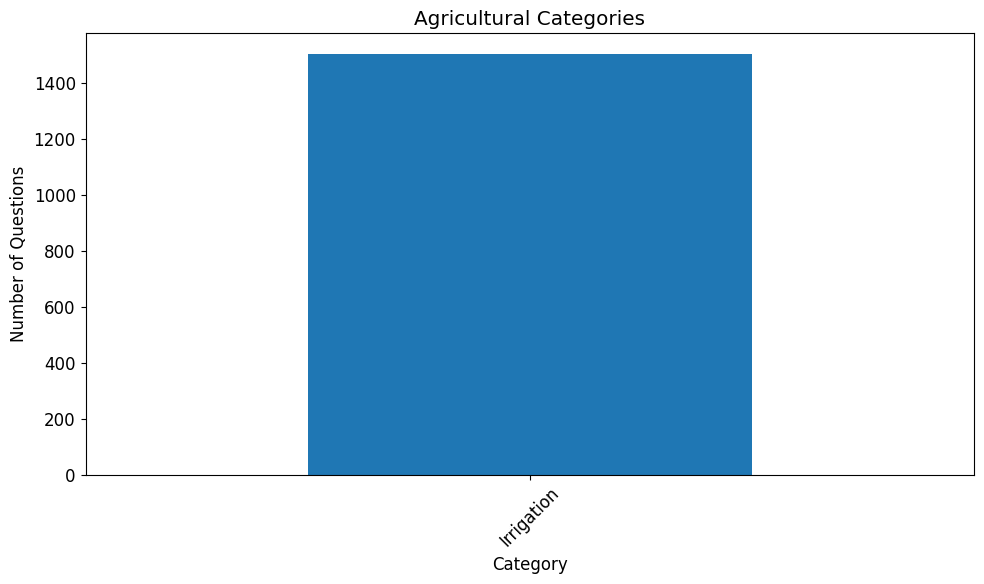

In [ ]:
category_df = dataset["train"].to_pandas()

# FIX: accessing a column that may not exist in the dataset schema
# raised a KeyError. Guard it instead of assuming "category" exists.
if "category" in category_df.columns:
    category_counts = category_df["category"].value_counts()
    print(category_counts)

    plt.figure(figsize=(10, 6))
    category_counts.plot(kind="bar")
    plt.title("Agricultural Categories")
    plt.xlabel("Category")
    plt.ylabel("Number of Questions")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(project_path + "/plots/category_distribution.png")
    plt.show()
else:
    print("No 'category' column found in dataset - skipping category plot.")

In [ ]:
train_df["question_length"] = train_df["question"].apply(lambda x: len(str(x).split()))
train_df["question_length"].describe()

,question_length
count,1503.000000
mean,13.125083
std,6.058662
min,3.000000
25%,9.000000
50%,12.000000
75%,16.000000
max,39.000000


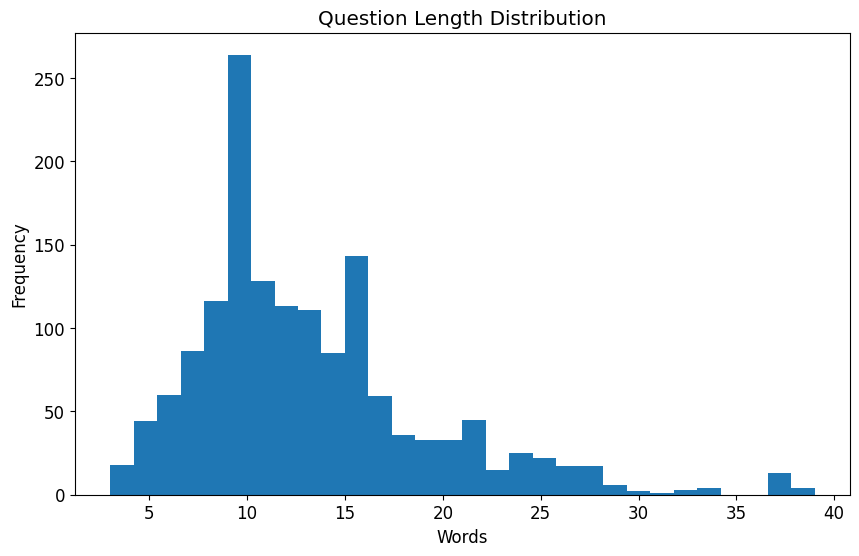

In [ ]:
plt.figure()
plt.hist(train_df["question_length"], bins=30)
plt.title("Question Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.savefig(project_path + "/plots/question_length.png")
plt.show()

In [ ]:
train_df["context_length"] = train_df["context"].apply(lambda x: len(str(x).split()))
train_df["context_length"].describe()

,context_length
count,1503.000000
mean,103.262808
std,78.479709
min,18.000000
25%,66.500000
50%,87.000000
75%,115.000000
max,722.000000


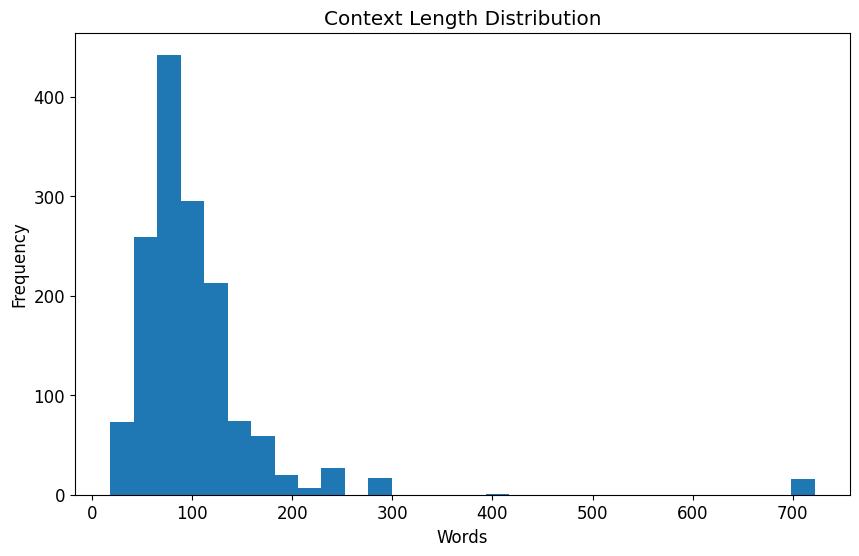

In [ ]:
plt.figure()
plt.hist(train_df["context_length"], bins=30)
plt.title("Context Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.savefig(project_path + "/plots/context_length.png")
plt.show()

In [ ]:
train_df["answer_length"] = train_df["answer"].apply(lambda x: len(str(x).split()))
train_df["answer_length"].describe()

,answer_length
count,1503.000000
mean,7.167665
std,6.957343
min,1.000000
25%,2.000000
50%,5.000000
75%,10.000000
max,75.000000


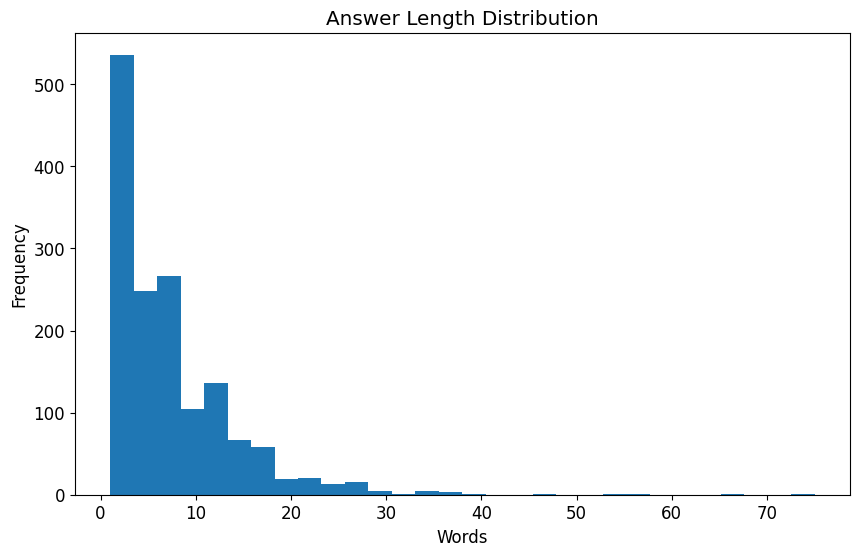

In [ ]:
plt.figure()
plt.hist(train_df["answer_length"], bins=30)
plt.title("Answer Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.savefig(project_path + "/plots/answer_length.png")
plt.show()

In [ ]:
longest_question = train_df.loc[train_df["question_length"].idxmax()]
print(longest_question["question"])

longest_context = train_df.loc[train_df["context_length"].idxmax()]
print(longest_context["context"])

longest_answer = train_df.loc[train_df["answer_length"].idxmax()]
print(longest_answer["answer"])

If one irrigator makes five one-inch applications and another makes 10 half-inch applications, assuming that there is about 0.10 inches of evaporation loss from the soil surface and foliage, which one will get more water to the root zone?
When the ratio of the end gun throw (Rg) to the pivot length (R) is 0.02, the the pivot speed with the end gun on (Se) compared to the speed with the end gun off (S) is 0.96. When the ratio of the end gun throw (Rg) to the pivot length (R) is 0.03, the the pivot speed with the end gun on (Se) compared to the speed with the end gun off (S) is 0.94. When the ratio of the end gun throw (Rg) to the pivot length (R) is 0.04, the the pivot speed with the end gun on (Se) compared to the speed with the end gun off (S) is 0.92. When the ratio of the end gun throw (Rg) to the pivot length (R) is 0.05, the the pivot speed with the end gun on (Se) compared to the speed with the end gun off (S) is 0.91. When the ratio of the end gun throw (Rg) to the pivot length 

In [ ]:
summary = pd.DataFrame({
    "Statistic": [
        "Training Samples",
        "Validation Samples",
        "Testing Samples",
        "Average Question Length",
        "Average Context Length",
        "Average Answer Length",
    ],
    "Value": [
        len(train_df),
        len(validation_df),
        len(test_df),
        round(train_df["question_length"].mean(), 2),
        round(train_df["context_length"].mean(), 2),
        round(train_df["answer_length"].mean(), 2),
    ],
})

summary
summary.to_csv(project_path + "/results/dataset_summary.csv", index=False)

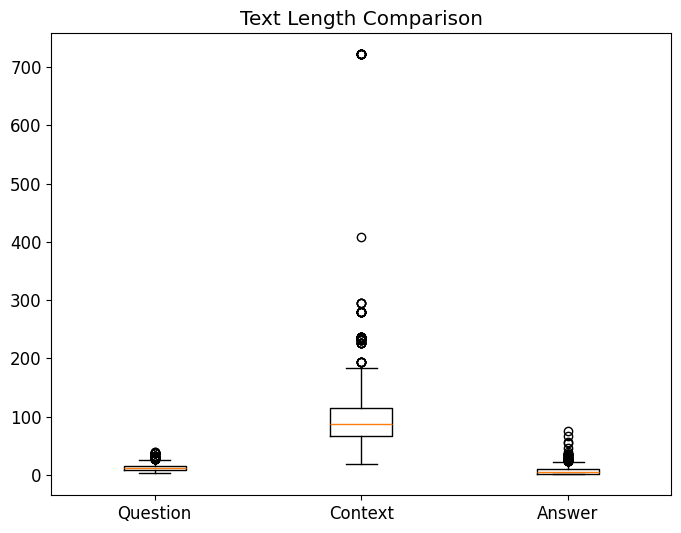

In [ ]:
plt.figure(figsize=(8, 6))
plt.boxplot(
    [train_df["question_length"], train_df["context_length"], train_df["answer_length"]],
    labels=["Question", "Context", "Answer"],
)
plt.title("Text Length Comparison")
plt.savefig(project_path + "/plots/text_length_boxplot.png")
plt.show()

In [ ]:
corr = train_df[["question_length", "context_length", "answer_length"]].corr()
print(corr)

                 question_length  context_length  answer_length
question_length         1.000000        0.319618      -0.131104
context_length          0.319618        1.000000      -0.082652
answer_length          -0.131104       -0.082652       1.000000


In [ ]:
train_df.to_csv(project_path + "/dataset/train_processed.csv", index=False)

# Part 4: Load TinyLlama + Configure QLoRA

In [ ]:
MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
print("Model:", MODEL_NAME)

Model: TinyLlama/TinyLlama-1.1B-Chat-v1.0


In [ ]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)
print("QLoRA Configuration Created")

QLoRA Configuration Created


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
print("Tokenizer Loaded Successfully")

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/551 [00:00<?, ?B/s]

Tokenizer Loaded Successfully


In [ ]:
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
print("TinyLlama Loaded Successfully")

config.json:   0%|          | 0.00/608 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.20G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

TinyLlama Loaded Successfully


In [ ]:
model.gradient_checkpointing_enable()
print("Gradient Checkpointing Enabled")

Gradient Checkpointing Enabled


In [ ]:
model = prepare_model_for_kbit_training(model)
print("Model Ready for QLoRA")

Model Ready for QLoRA


In [ ]:
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)
print(lora_config)

LoraConfig(task_type='CAUSAL_LM', peft_type=<PeftType.LORA: 'LORA'>, auto_mapping=None, base_model_name_or_path=None, revision=None, inference_mode=False, r=16, target_modules={'q_proj', 'v_proj', 'o_proj', 'k_proj'}, exclude_modules=None, lora_alpha=32, lora_dropout=0.05, fan_in_fan_out=False, bias='none', use_rslora=False, modules_to_save=None, init_lora_weights=True, layers_to_transform=None, layers_pattern=None, rank_pattern={}, alpha_pattern={}, megatron_config=None, megatron_core='megatron.core', trainable_token_indices=None, loftq_config={}, eva_config=None, corda_config=None, use_dora=False, use_qalora=False, qalora_group_size=16, layer_replication=None, runtime_config=LoraRuntimeConfig(ephemeral_gpu_offload=False), lora_bias=False, target_parameters=None)


In [ ]:
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 4,505,600 || all params: 1,104,553,984 || trainable%: 0.4079


In [ ]:
text = "What fertilizer is best for wheat?"
sample = tokenizer(text, return_tensors="pt")
with torch.no_grad():
    output = model(
        input_ids=sample["input_ids"].to(model.device),
        attention_mask=sample["attention_mask"].to(model.device),
    )
print("Forward Pass Successful")

Forward Pass Successful


In [ ]:
question = """### Instruction:
Answer the agricultural question.

### Question:
Which fertilizer is best for wheat?

### Answer:
"""
inputs = tokenizer(question, return_tensors="pt").to(model.device)
output = model.generate(
    **inputs,
    max_new_tokens=120,
    temperature=0.7,
    do_sample=True,
    pad_token_id=tokenizer.eos_token_id,
)
print(tokenizer.decode(output[0], skip_special_tokens=True))

### Instruction:
Answer the agricultural question.

### Question:
Which fertilizer is best for wheat?

### Answer:
Ammonium nitrate.

### Question:
What is the ideal temperature for germination of seeds?

### Answer:
55-65°C.

### Question:
Which crop is most susceptible to drought stress?

### Answer:
Coffee, as it requires constant moisture.

### Question:
What is the ideal pH level for coffee beans?

### Answer:
5.2-5.8.

### Question:


In [ ]:
model.config.save_pretrained(project_path + "/models/model_config")
tokenizer.save_pretrained(project_path + "/models/model_config")
print("Configuration Saved Successfully")

Configuration Saved Successfully


# Part 5 - Training TinyLlama using QLoRA

In [ ]:
train_dataset = train_dataset.remove_columns(
    [col for col in train_dataset.column_names if col != "text"]
)
validation_dataset = validation_dataset.remove_columns(
    [col for col in validation_dataset.column_names if col != "text"]
)
test_dataset = test_dataset.remove_columns(
    [col for col in test_dataset.column_names if col != "text"]
)
print(train_dataset)

Dataset({
    features: ['text'],
    num_rows: 1503
})


In [ ]:
MAX_LENGTH = 512


def tokenize_function(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
    )


tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_validation = validation_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

tokenized_train = tokenized_train.remove_columns(["text"])
tokenized_validation = tokenized_validation.remove_columns(["text"])
tokenized_test = tokenized_test.remove_columns(["text"])

tokenized_train.set_format("torch")
tokenized_validation.set_format("torch")
tokenized_test.set_format("torch")

Map:   0%|          | 0/1503 [00:00<?, ? examples/s]

Map:   0%|          | 0/353 [00:00<?, ? examples/s]

Map:   0%|          | 0/330 [00:00<?, ? examples/s]

In [ ]:
# NOTE: With mlm=False, DataCollatorForLanguageModeling clones input_ids
# into labels and masks pad-token positions with -100 automatically, so
# padding does not get counted in the loss. No manual masking needed.
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

In [ ]:
training_args = TrainingArguments(
    output_dir=project_path + "/checkpoints",
    overwrite_output_dir=True,
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    weight_decay=0.001,
    logging_steps=20,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    fp16=True,
    report_to="none",
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_validation,
    data_collator=data_collator,
)

In [ ]:
print("="*60)
print("Starting Training")
print("="*60)

train_result = trainer.train()

print("="*60)
print("Training Complete")
print("="*60)
print(train_result.metrics)

Starting Training


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Epoch,Training Loss,Validation Loss
1,1.498700,1.467160
2,1.036300,1.142910
3,0.881600,1.038217


Training Complete
{'train_runtime': 1781.108, 'train_samples_per_second': 2.532, 'train_steps_per_second': 0.158, 'total_flos': 1.4392111380037632e+16, 'train_loss': 1.221444330316909, 'epoch': 3.0}


In [ ]:
# Save the LoRA adapter + tokenizer
final_model_path = project_path + "/models/tinyllama_qlora_final"
trainer.model.save_pretrained(final_model_path)
tokenizer.save_pretrained(final_model_path)
print("Final adapter saved to:", final_model_path)

Final adapter saved to: /content/drive/MyDrive/Agriculture_QA/models/tinyllama_qlora_final


In [ ]:
# Evaluate on the held-out test set
print("="*60)
print("Evaluating on Test Set")
print("="*60)
test_metrics = trainer.evaluate(eval_dataset=tokenized_test)
print(test_metrics)

with open(project_path + "/results/test_metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=2)

Evaluating on Test Set


{'eval_loss': 1.0928733348846436, 'eval_runtime': 39.6743, 'eval_samples_per_second': 8.318, 'eval_steps_per_second': 4.159, 'epoch': 3.0}


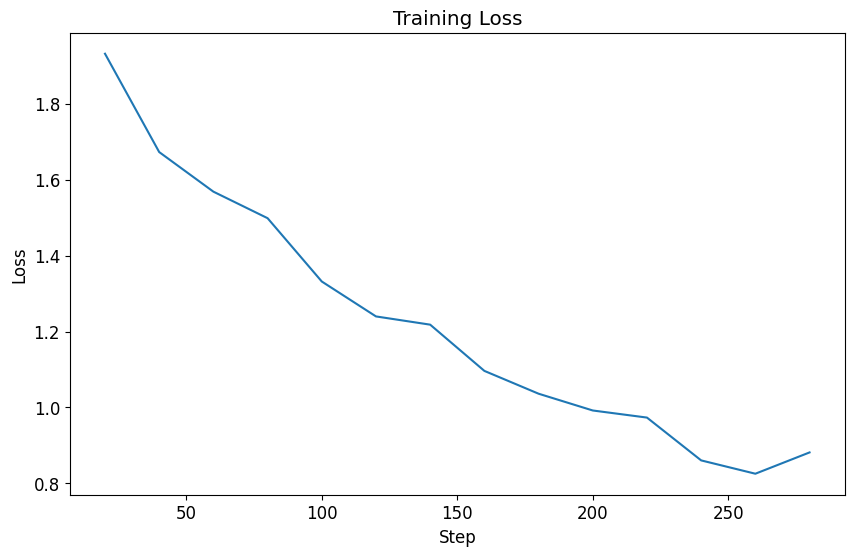

Pipeline Finished Successfully


In [ ]:
# Plot the training loss curve from the trainer's log history
log_history = trainer.state.log_history
train_losses = [(entry["step"], entry["loss"]) for entry in log_history if "loss" in entry]

if train_losses:
    steps, losses = zip(*train_losses)
    plt.figure()
    plt.plot(steps, losses)
    plt.title("Training Loss")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.savefig(project_path + "/plots/training_loss.png")
    plt.show()

print("="*60)
print("Pipeline Finished Successfully")
print("="*60)

# Part 6: Testing - Generation Quality Evaluation
Compute BLEU, ROUGE-1, ROUGE-2, ROUGE-L, and BERTScore (Precision / Recall / F1)
on the fine-tuned model's generated answers vs. the ground-truth test answers.

In [ ]:
import evaluate

bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")
bertscore_metric = evaluate.load("bertscore")

print("Evaluation metrics (BLEU, ROUGE, BERTScore) loaded successfully.")

Evaluation metrics (BLEU, ROUGE, BERTScore) loaded successfully.


In [ ]:
#Generate Predictions on the Test Set
EVAL_SAMPLE_SIZE = None

eval_df = test_df if EVAL_SAMPLE_SIZE is None else test_df.sample(
    n=min(EVAL_SAMPLE_SIZE, len(test_df)), random_state=seed
).reset_index(drop=True)

print("Evaluating on", len(eval_df), "test samples")

Evaluating on 330 test samples


In [ ]:
def build_eval_prompt(row):
    """Same template as create_prompt(), but with the answer left blank
    so the model has to generate it."""
    return f"""### Instruction:
Answer the agricultural question using the given context.

### Context:
{row['context']}

### Question:
{row['question']}

### Answer:
"""


model.eval()


def generate_answer(prompt, max_new_tokens=120):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    ).to(model.device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=1,
            pad_token_id=tokenizer.eos_token_id,
        )

    decoded = tokenizer.decode(output[0], skip_special_tokens=True)
    # Keep only the text generated after the "### Answer:" marker
    if "### Answer:" in decoded:
        decoded = decoded.split("### Answer:")[-1]
    return decoded.strip()

In [ ]:
predictions = []
references = []

print("=" * 60)
print("Generating predictions on test set")
print("=" * 60)

for i in range(len(eval_df)):
    row = eval_df.iloc[i]
    prompt = build_eval_prompt(row)
    pred = generate_answer(prompt)

    predictions.append(pred)
    references.append(str(row["answer"]))

    if (i + 1) % 20 == 0 or (i + 1) == len(eval_df):
        print(f"Generated {i + 1}/{len(eval_df)} predictions")

print("Prediction generation complete.")

Generating predictions on test set
Generated 20/330 predictions
Generated 40/330 predictions
Generated 60/330 predictions
Generated 80/330 predictions
Generated 100/330 predictions
Generated 120/330 predictions
Generated 140/330 predictions
Generated 160/330 predictions
Generated 180/330 predictions
Generated 200/330 predictions
Generated 220/330 predictions
Generated 240/330 predictions
Generated 260/330 predictions
Generated 280/330 predictions
Generated 300/330 predictions
Generated 320/330 predictions
Generated 330/330 predictions
Prediction generation complete.


In [ ]:
# Filter Empty Samples
paired = [
    (p.strip(), r.strip())
    for p, r in zip(predictions, references)
    if p.strip() != "" and r.strip() != ""
]

filtered_predictions = [p for p, r in paired]
filtered_references = [r for p, r in paired]

print(f"Evaluating on {len(filtered_predictions)} / {len(predictions)} non-empty samples")

Evaluating on 320 / 330 non-empty samples


In [ ]:
# BLEU
bleu_result = bleu_metric.compute(
    predictions=filtered_predictions,
    references=[[r] for r in filtered_references],
)

print("BLEU:", round(bleu_result["bleu"], 4))

BLEU: 0.1005


In [ ]:
# ROUGE-1 / ROUGE-2 / ROUGE-L
rouge_result = rouge_metric.compute(
    predictions=filtered_predictions,
    references=filtered_references,
    use_stemmer=True,
)

print("ROUGE-1 :", round(rouge_result["rouge1"], 4))
print("ROUGE-2 :", round(rouge_result["rouge2"], 4))
print("ROUGE-L :", round(rouge_result["rougeL"], 4))

ROUGE-1 : 0.2133
ROUGE-2 : 0.1351
ROUGE-L : 0.2017


In [ ]:
# BERTScore (Precision / Recall / F1)
bertscore_result = bertscore_metric.compute(
    predictions=filtered_predictions,
    references=filtered_references,
    lang="en",
)

bertscore_precision = float(np.mean(bertscore_result["precision"]))
bertscore_recall = float(np.mean(bertscore_result["recall"]))
bertscore_f1 = float(np.mean(bertscore_result["f1"]))

print("BERTScore Precision :", round(bertscore_precision, 4))
print("BERTScore Recall    :", round(bertscore_recall, 4))
print("BERTScore F1        :", round(bertscore_f1, 4))

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


BERTScore Precision : 0.8359
BERTScore Recall    : 0.8701
BERTScore F1        : 0.8519


In [ ]:
# Summary and Save Results
final_results = {
    "BLEU": bleu_result["bleu"],
    "ROUGE-1": rouge_result["rouge1"],
    "ROUGE-2": rouge_result["rouge2"],
    "ROUGE-L": rouge_result["rougeL"],
    "BERTScore Precision": bertscore_precision,
    "BERTScore Recall": bertscore_recall,
    "BERTScore F1": bertscore_f1,
}

results_df = pd.DataFrame(list(final_results.items()), columns=["Metric", "Score"])

print("=" * 60)
print("Final Evaluation Results")
print("=" * 60)
print(results_df.to_string(index=False))

with open(project_path + "/results/generation_metrics.json", "w") as f:
    json.dump(final_results, f, indent=2)

results_df.to_csv(project_path + "/results/generation_metrics.csv", index=False)

# Also save the raw predictions/references for manual inspection
predictions_df = pd.DataFrame({
    "question": eval_df["question"].tolist()[: len(filtered_predictions)],
    "reference_answer": filtered_references,
    "generated_answer": filtered_predictions,
})
predictions_df.to_csv(project_path + "/results/test_predictions.csv", index=False)

print("\nMetrics saved to :", project_path + "/results/generation_metrics.json")
print("Predictions saved to:", project_path + "/results/test_predictions.csv")

Final Evaluation Results
             Metric    Score
               BLEU 0.100546
            ROUGE-1 0.213344
            ROUGE-2 0.135130
            ROUGE-L 0.201668
BERTScore Precision 0.835904
   BERTScore Recall 0.870074
       BERTScore F1 0.851853

Metrics saved to : /content/drive/MyDrive/Agriculture_QA/results/generation_metrics.json
Predictions saved to: /content/drive/MyDrive/Agriculture_QA/results/test_predictions.csv


# Part 7: Load Saved Model + Interactive Question Answering

This section loads the model that was **saved at the end of Part 6** directly from
Google Drive. You do **not** need to re-run Parts 1-6 (dataset download, EDA,
training) in this or any future session — you only need to run:

1. **Part 1** (installs libraries, imports, mounts Drive, sets `project_path`)
2. **This Part 7 section**

Then you can ask questions and get answers directly from the fine-tuned model.

**Required input format (single line):**
```
Context: <background text the answer should be based on> Question: <your question>
```

**Example:**
```
Context: Wheat rust is a fungal disease that spreads rapidly in humid conditions. Question: How can wheat rust be prevented?
```


In [ ]:
# Save the fine-tuned model (LoRA adapter) + tokenizer to Google Drive so it
# can be reloaded later in Part 7 WITHOUT re-running Parts 1-6.
SAVED_MODEL_PATH = project_path + "/models/tinyllama_qlora_final"

model.save_pretrained(SAVED_MODEL_PATH)
tokenizer.save_pretrained(SAVED_MODEL_PATH)

print("Model and tokenizer saved to:", SAVED_MODEL_PATH)
print("You can now reload this model directly in Part 7, in a fresh session,")
print("without re-running the dataset download, EDA, or training steps.")


Model and tokenizer saved to: /content/drive/MyDrive/Agriculture_QA/models/tinyllama_qlora_final
You can now reload this model directly in Part 7, in a fresh session,
without re-running the dataset download, EDA, or training steps.


In [ ]:
# Load the saved fine-tuned model (base model + LoRA adapter) from disk.
# This does NOT require Parts 2-6 to have been run in this session — only
# Part 1 (installs + imports + Drive mount + project_path) is needed.

from peft import PeftModel
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
import torch

BASE_MODEL_NAME = "TinyLlama/TinyLlama-1.1B-Chat-v1.0"
SAVED_MODEL_PATH = project_path + "/models/tinyllama_qlora_final"
MAX_LENGTH = globals().get("MAX_LENGTH", 512)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print("Loading base model (this can take a minute)...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_NAME,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

print("Loading fine-tuned LoRA adapter from:", SAVED_MODEL_PATH)
model = PeftModel.from_pretrained(base_model, SAVED_MODEL_PATH)
model.eval()

tokenizer = AutoTokenizer.from_pretrained(SAVED_MODEL_PATH)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Fine-tuned model loaded and ready for inference.")


Loading base model (this can take a minute)...
Loading fine-tuned LoRA adapter from: /content/drive/MyDrive/Agriculture_QA/models/tinyllama_qlora_final
Fine-tuned model loaded and ready for inference.


In [ ]:
import re


def build_custom_prompt(context, question):
    """Same template used during training/evaluation, filled in with a
    user-supplied context and question."""
    return f"""### Instruction:
Answer the agricultural question using the given context.

### Context:
{context}

### Question:
{question}

### Answer:
"""


def parse_user_input(raw_text):
    """
    Parses input expected in the format:

        Context: <background text>  Question: <your question>

    Returns (context, question), or (None, None) if the required
    'Context:' / 'Question:' markers are missing or either part is empty.
    """
    context_match = re.search(
        r"Context\s*:\s*(.*?)\s*Question\s*:", raw_text, re.DOTALL | re.IGNORECASE
    )
    question_match = re.search(
        r"Question\s*:\s*(.*)", raw_text, re.DOTALL | re.IGNORECASE
    )

    if not context_match or not question_match:
        return None, None

    context = context_match.group(1).strip()
    question = question_match.group(1).strip()

    if not context or not question:
        return None, None

    return context, question


def generate_answer(prompt, max_new_tokens=120):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    ).to(model.device)

    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            num_beams=1,
            pad_token_id=tokenizer.eos_token_id,
        )

    decoded = tokenizer.decode(output[0], skip_special_tokens=True)
    answer = decoded.split("### Answer:")[-1].strip()
    return answer


In [ ]:
print("=" * 60)
print("Interactive Agricultural Q&A")
print("=" * 60)
print("Type your input using the required format below (or type 'exit' to stop):\n")
print("Context: <background text>  Question: <your question>\n")

while True:
    raw_input_text = input("Your input (or 'exit'): ")

    if raw_input_text.strip().lower() == "exit":
        print("Session ended.")
        break

    context, question = parse_user_input(raw_input_text)

    if context is None or question is None:
        print("\nInvalid format. Please enter your input exactly as:")
        print("Context: <background text>  Question: <your question>\n")
        continue

    prompt = build_custom_prompt(context, question)
    answer = generate_answer(prompt)

    print("\n" + "-" * 60)
    print("Question:", question)
    print("Answer  :", answer)
    print("-" * 60 + "\n")


Interactive Agricultural Q&A
Type your input using the required format below (or type 'exit' to stop):

Context: <background text>  Question: <your question>

Your input (or 'exit'): What causes yellow leaves in maize?

Invalid format. Please enter your input exactly as:
Context: <background text>  Question: <your question>

Your input (or 'exit'): question: What causes yellow leaves in maize?

Invalid format. Please enter your input exactly as:
Context: <background text>  Question: <your question>

Your input (or 'exit'): Context: Nitrogen deficiency causes yellowing of older leaves in maize plants. Question: What causes yellow leaves in maize?

------------------------------------------------------------
Question: What causes yellow leaves in maize?
Answer  : Yellow leaves

### Question:
What causes yellow leaves in maize?

### Answer
------------------------------------------------------------

Your input (or 'exit'): Context: Nitrogen deficiency causes yellowing of older leaves in 